# GNN Efficiency Collapse at Low Multiplicity

## Formal explanation

The tracking pipeline contains two trained models:

- **Metric-learning / latent model** — trained on `100_mixed` events (~400 particles/event)
- **GNN edge classifier** — trained on `300_MIXED` events (~300 particles/event)

Both are applied unchanged to OOD test events with as few as 40–80 particles per event.

### Why the GNN recall collapses

The GNN uses **Batch Normalization** with `track_running_stats = False`. This means that at inference the normalisation statistics (mean $\mu_\mathcal{B}$, variance $\sigma^2_\mathcal{B}$) are computed from the *current batch* rather than a stored exponential moving average accumulated during training:

$$\hat{x}_i = \frac{x_i - \mu_\mathcal{B}}{\sqrt{\sigma^2_\mathcal{B} + \varepsilon}}$$

During training on dense events the per-layer activations are drawn from a stable distribution — the batch statistics are a good proxy for the population statistics. At inference on a sparse event ($N_{\text{hits}} \sim 450$ vs $\sim 1{,}300$ during training), the activations occupy a different region of feature space. The batch statistics computed from that single sparse event diverge from the training-time statistics, pushing the normalised activations out of the regime where the learned decision boundary operates.

The consequence is that the sigmoid output collapses towards 0 for *all* edges — both true and false — so essentially no edge crosses the 0.5 threshold:

| ppv | particles/event | true-edge recall | efficiency |
|----:|----------------:|-----------------:|-----------:|
| 10  |  40             |  5.8 %           | ~0 %       |
| 20  |  80             | 42.0 %           | 12 %       |
| 30  | 120             | 94.4 %           | 93 %       |

The fake-edge pass rate remains essentially 0 % throughout — the model is not confused, it is *silent*. The transition near ppv ≈ 25–30 marks where the event density becomes close enough to the training distribution for the GNN to operate correctly.

### Possible remedies
- Re-train with **mixed-multiplicity** data (including low-ppv events)
- Switch to **Layer Normalization** (normalises over feature dimension, independent of batch/graph size)
- Use **running statistics** (`track_running_stats = True`) so inference uses the population statistics accumulated during training
- Apply a **score recalibration** — shift/scale the raw logit per event to account for the changed activation statistics

In [1]:
import sys
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

PIPELINE = Path("/data/alice/bkuipers/low_pt_gnn_pipeline")
N_FILES   = 20   # events to sample per ppv
PPV_LIST  = [10, 20, 30, 40, 50, 60, 80, 100, 150, 200]

In [2]:
def load_scores(ppv, n=N_FILES):
    """Return (true_scores, false_scores) arrays for the first n testset events."""
    d_dir = PIPELINE / f"data_{ppv}" / "gnn_stage" / "testset"
    files = sorted(d_dir.glob("*.pyg"))[:n]
    true_s, false_s = [], []
    for f in files:
        d = torch.load(f, weights_only=False)
        scores = d.get("edge_scores", d.get("scores"))
        y      = d.get("edge_y",     d.get("y"))
        if scores is None or y is None:
            continue
        mask = y.bool()
        true_s.append(scores[mask].numpy())
        false_s.append(scores[~mask].numpy())
    return np.concatenate(true_s), np.concatenate(false_s)

data = {ppv: load_scores(ppv) for ppv in PPV_LIST}
print("Loaded:", {ppv: (len(v[0]), len(v[1])) for ppv, v in data.items()})

/data/alice/bkuipers/miniconda3/envs/acorn_notebook/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded: {10: (15314, 247808), 20: (30648, 930118), 30: (44904, 1949252), 40: (60372, 3570413), 50: (75132, 5404290), 60: (90092, 7349909), 80: (119722, 11273934), 100: (150660, 15167932), 150: (225950, 23985092), 200: (300676, 32317218)}


## 1 — Edge score distributions: true vs false edges at each multiplicity

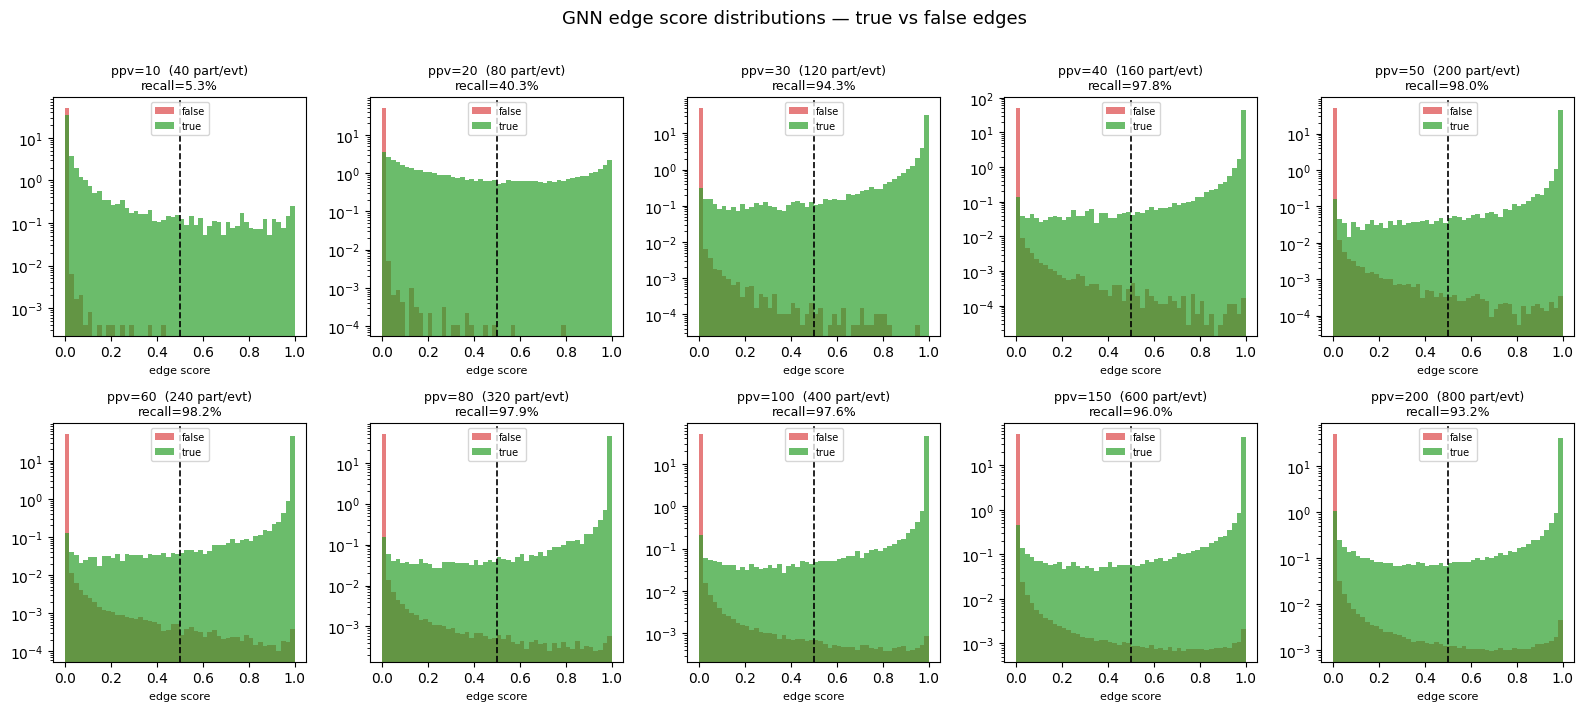

In [3]:
n_cols = 5
n_rows = int(np.ceil(len(PPV_LIST) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows), sharey=False)
axes = axes.flatten()

bins = np.linspace(0, 1, 51)

for ax, ppv in zip(axes, PPV_LIST):
    true_s, false_s = data[ppv]
    recall = (true_s > 0.5).mean() * 100
    ax.hist(false_s, bins=bins, color="#d62728", alpha=0.6, density=True, label="false")
    ax.hist(true_s,  bins=bins, color="#2ca02c", alpha=0.7, density=True, label="true")
    ax.axvline(0.5, color="black", lw=1.2, ls="--")
    ax.set_title(f"ppv={ppv}  ({ppv*4} part/evt)\nrecall={recall:.1f}%", fontsize=9)
    ax.set_xlabel("edge score", fontsize=8)
    ax.set_yscale("log")
    ax.legend(fontsize=7, loc="upper center")

for ax in axes[len(PPV_LIST):]:
    ax.set_visible(False)

fig.suptitle("GNN edge score distributions — true vs false edges", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 2 — Recall and mean true-edge score vs multiplicity

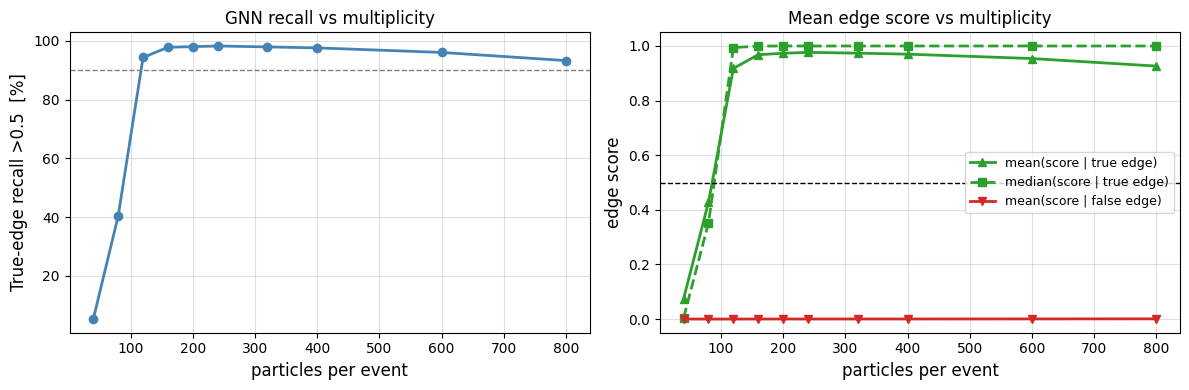

In [4]:
ppvs          = PPV_LIST
recalls       = [(data[p][0] > 0.5).mean() * 100 for p in ppvs]
mean_true     = [data[p][0].mean()               for p in ppvs]
mean_false    = [data[p][1].mean()               for p in ppvs]
median_true   = [np.median(data[p][0])           for p in ppvs]
x_axis        = [p * 4 for p in ppvs]  # total particles per event

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(x_axis, recalls, marker="o", color="steelblue", lw=2)
ax.set_xlabel("particles per event", fontsize=12)
ax.set_ylabel("True-edge recall >0.5  [%]", fontsize=12)
ax.set_title("GNN recall vs multiplicity")
ax.axhline(90, ls="--", color="gray", lw=1)
ax.grid(True, alpha=0.4)

ax = axes[1]
ax.plot(x_axis, mean_true,  marker="^", color="#2ca02c", lw=2, label="mean(score | true edge)")
ax.plot(x_axis, median_true, marker="s", color="#2ca02c", lw=2, ls="--", label="median(score | true edge)")
ax.plot(x_axis, mean_false, marker="v", color="#d62728", lw=2, label="mean(score | false edge)")
ax.axhline(0.5, ls="--", color="black", lw=1)
ax.set_xlabel("particles per event", fontsize=12)
ax.set_ylabel("edge score", fontsize=12)
ax.set_title("Mean edge score vs multiplicity")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)

fig.tight_layout()
plt.show()

## 3 — Score percentiles for true edges: how the distribution shifts

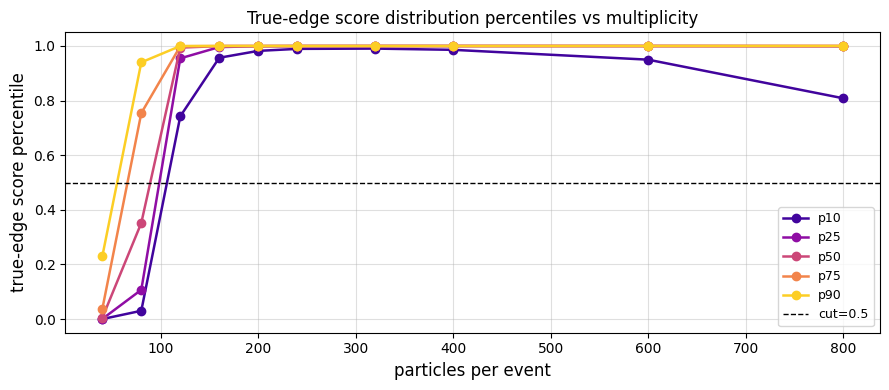

In [5]:
percentiles = [10, 25, 50, 75, 90]
pct_vals    = {p: np.percentile(data[ppv][0], p) for p in percentiles for ppv in ppvs}
# reshape
pct_matrix  = {p: [np.percentile(data[ppv][0], p) for ppv in ppvs] for p in percentiles}

fig, ax = plt.subplots(figsize=(9, 4))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(percentiles)))
for pct, col in zip(percentiles, colors):
    ax.plot(x_axis, pct_matrix[pct], marker="o", lw=1.8, color=col, label=f"p{pct}")

ax.axhline(0.5, ls="--", color="black", lw=1, label="cut=0.5")
ax.set_xlabel("particles per event", fontsize=12)
ax.set_ylabel("true-edge score percentile", fontsize=12)
ax.set_title("True-edge score distribution percentiles vs multiplicity")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)
fig.tight_layout()
plt.show()

## 4 — Per-event statistics: are all events equally affected or is there spread?

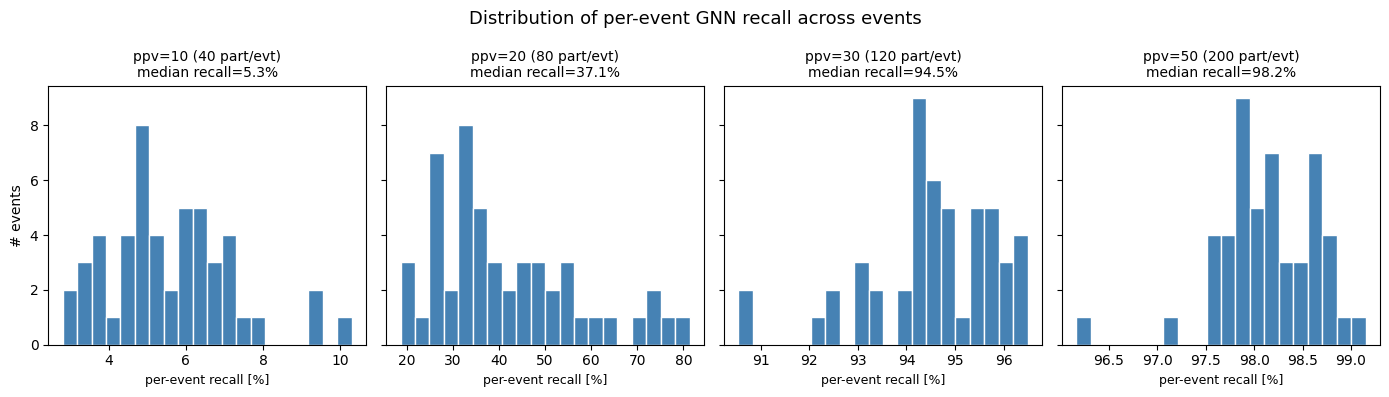

In [6]:
focus_ppvs = [10, 20, 30, 50]
n_events   = 50

fig, axes = plt.subplots(1, len(focus_ppvs), figsize=(14, 4), sharey=True)

for ax, ppv in zip(axes, focus_ppvs):
    d_dir = PIPELINE / f"data_{ppv}" / "gnn_stage" / "testset"
    files = sorted(d_dir.glob("*.pyg"))[:n_events]
    per_event_recall = []
    for f in files:
        d = torch.load(f, weights_only=False)
        scores = d.get("edge_scores", d.get("scores"))
        y      = d.get("edge_y",     d.get("y"))
        if scores is None or y is None or y.sum() == 0:
            continue
        mask = y.bool()
        per_event_recall.append((scores[mask] > 0.5).float().mean().item() * 100)
    ax.hist(per_event_recall, bins=20, color="steelblue", edgecolor="white")
    ax.set_title(f"ppv={ppv} ({ppv*4} part/evt)\nmedian recall={np.median(per_event_recall):.1f}%", fontsize=10)
    ax.set_xlabel("per-event recall [%]", fontsize=9)

axes[0].set_ylabel("# events", fontsize=10)
fig.suptitle("Distribution of per-event GNN recall across events", fontsize=13)
fig.tight_layout()
plt.show()

## 5 — Does the graph construction (latent KNN) already fail, or only the GNN?

Check whether true edges are *present* in the KNN graph before GNN scoring, or if they were never proposed.

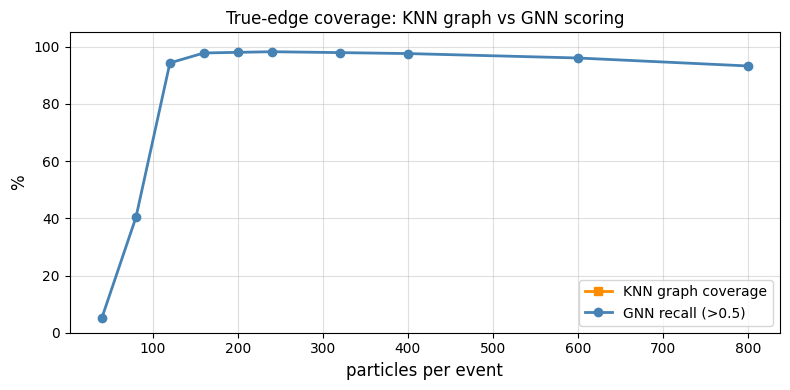

KNN coverage: {10: '199.8%', 20: '199.7%', 30: '199.7%', 40: '199.5%', 50: '199.7%', 60: '199.7%', 80: '199.6%', 100: '199.5%', 150: '199.1%', 200: '198.8%'}


In [7]:
def knn_true_edge_coverage(ppv, n=N_FILES):
    """Fraction of ground-truth track edges that appear in the KNN graph (edge_y=1)."""
    d_dir = PIPELINE / f"data_{ppv}" / "gnn_stage" / "testset"
    files = sorted(d_dir.glob("*.pyg"))[:n]
    total_gt, found = 0, 0
    for f in files:
        d = torch.load(f, weights_only=False)
        y = d.get("edge_y", d.get("y"))
        track_edges = d.get("track_edges")
        if y is None:
            continue
        # edge_y==1 means the KNN graph contains this true edge
        found     += y.sum().item()
        # total ground truth edges from track_edges
        total_gt  += track_edges.shape[1] if track_edges is not None else y.sum().item()
    return 100 * found / total_gt if total_gt else 0

knn_coverage = {ppv: knn_true_edge_coverage(ppv) for ppv in PPV_LIST}

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_axis, [knn_coverage[p] for p in ppvs], marker="s", color="darkorange", lw=2, label="KNN graph coverage")
ax.plot(x_axis, recalls, marker="o", color="steelblue", lw=2, label="GNN recall (>0.5)")
ax.set_xlabel("particles per event", fontsize=12)
ax.set_ylabel("%", fontsize=12)
ax.set_title("True-edge coverage: KNN graph vs GNN scoring")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_ylim(0, 105)
fig.tight_layout()
plt.show()

print("KNN coverage:", {ppv: f"{knn_coverage[ppv]:.1f}%" for ppv in ppvs})

## 6 — Live KNN sweep on a single data_10 event

Rebuild the KNN graph from stored embeddings with variable `k_max` / `r_max`, re-run the GNN, run CC track building, and report efficiency — no plots, just numbers.

In [8]:
import sys, copy
import torch
import numpy as np
from pathlib import Path

ACORN_ROOT = Path("/data/alice/bkuipers/acorn")
GNN_CKPT   = PIPELINE / "saved_models/Low_pt_gnn_300_MIXED_1i1o_best_val_loss=0.0007.ckpt"
DATA_DIR   = PIPELINE / "data_10" / "gnn_stage" / "testset"  # embeddings stored here

for p in [str(ACORN_ROOT), str(PIPELINE)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from acorn.stages.edge_classifier.models.interaction_gnn import InteractionGNN

gnn = InteractionGNN.load_from_checkpoint(GNN_CKPT, map_location="cpu")
gnn.eval()

N_EVENTS = 10
graphs = [torch.load(f, weights_only=False)
          for f in sorted(DATA_DIR.glob("*.pyg"))[:N_EVENTS]]
print(f"GNN loaded | {len(graphs)} events from data_10")


# ── helpers ───────────────────────────────────────────────────────────────────

def build_knn_from_embeddings(emb: torch.Tensor, k_max: int, r_max: float) -> torch.Tensor:
    n = emb.shape[0]
    dists = torch.cdist(emb.float(), emb.float())
    dists.fill_diagonal_(float("inf"))
    k = min(k_max, n - 1)
    topk_vals, topk_idx = dists.topk(k=k, dim=1, largest=False)
    src, dst = [], []
    for i in range(n):
        nbrs = topk_idx[i][topk_vals[i] < r_max]
        src.append(torch.full((len(nbrs),), i))
        dst.append(nbrs)
    src, dst = torch.cat(src), torch.cat(dst)
    edge_index = torch.unique(torch.stack([torch.cat([src, dst]),
                                           torch.cat([dst, src])]), dim=1)
    return edge_index


def infer_scores(graph, edge_index: torch.Tensor) -> torch.Tensor:
    g = copy.copy(graph)
    g.edge_index = edge_index
    g.num_nodes  = graph.num_nodes
    with torch.no_grad():
        raw = gnn(g)
    scores = torch.sigmoid(raw)
    if scores.shape[0] == 2 * edge_index.shape[1]:
        scores = scores.view(2, -1).mean(0)
    return scores


def union_find_cc(n: int, edges) -> list:
    """Union-Find connected components. Returns label list of length n."""
    parent = list(range(n))
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    for u, v in edges:
        pu, pv = find(int(u)), find(int(v))
        if pu != pv:
            parent[pu] = pv
    return [find(i) for i in range(n)]


def cc_efficiency(graph, scores, edge_index,
                  score_cut=0.5, min_hits=3, matching_fraction=0.5):
    n    = graph.num_nodes
    pids = graph.hit_particle_id.tolist()
    keep = (scores > score_cut).tolist()
    edges = [(int(edge_index[0, i]), int(edge_index[1, i]))
             for i in range(edge_index.shape[1]) if keep[i]]

    recon_pids = {p for p in pids if p > 0}
    n_particles = len(recon_pids)

    if not edges:
        return dict(eff=0.0, fake_rate=1.0, n_tracks=0, n_particles=n_particles)

    labels = union_find_cc(n, edges)

    from collections import Counter, defaultdict
    clusters = defaultdict(list)
    for i, lbl in enumerate(labels):
        clusters[lbl].append(i)

    matched, n_tracks, n_fake = set(), 0, 0
    for hits in clusters.values():
        if len(hits) < min_hits:
            continue
        n_tracks += 1
        cpids = [pids[i] for i in hits]
        best_pid, best_cnt = Counter(cpids).most_common(1)[0]
        if best_pid == 0:
            n_fake += 1
            continue
        frac_cluster  = best_cnt / len(hits)
        frac_particle = best_cnt / pids.count(best_pid)
        if frac_cluster >= matching_fraction and frac_particle >= matching_fraction:
            matched.add(best_pid)
        else:
            n_fake += 1

    return dict(eff=len(matched) / n_particles if n_particles else 0,
                fake_rate=n_fake / n_tracks if n_tracks else 0,
                n_tracks=n_tracks, n_particles=n_particles,
                n_matched=len(matched))


# ── sweep — edit K_SWEEP / R_SWEEP / SCORE_CUT freely ────────────────────────
K_SWEEP   = [35, 75, 150, 250]        # original pipeline uses 250
R_SWEEP   = [0.10, 0.14, 0.18, 0.24] # original pipeline uses 0.18
SCORE_CUT = 0.5

print(f"\n{'k_max':>6}  {'r_max':>6}  {'avg_deg':>8}  {'eff%':>7}  {'fake%':>7}")
print("-" * 45)

for k_max in K_SWEEP:
    for r_max in R_SWEEP:
        effs, fakes, degs = [], [], []
        for g in graphs:
            emb = g["embeddings"].float()
            ei  = build_knn_from_embeddings(emb, k_max=k_max, r_max=r_max)
            degs.append(ei.shape[1] / g.num_nodes)
            sc  = infer_scores(g, ei)
            res = cc_efficiency(g, sc, ei, score_cut=SCORE_CUT)
            effs.append(res["eff"])
            fakes.append(res["fake_rate"])
        print(f"{k_max:>6}  {r_max:>6.2f}  {np.mean(degs):>8.1f}"
              f"  {100*np.mean(effs):>6.1f}%  {100*np.mean(fakes):>6.1f}%")

/data/alice/bkuipers/miniconda3/envs/acorn_notebook/lib/python3.10/site-packages/lightning_fabric/__init__.py:40: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


GNN loaded | 10 events from data_10

 k_max   r_max   avg_deg     eff%    fake%
---------------------------------------------
    35    0.10       6.2     0.0%   100.0%
    35    0.14      17.6     0.0%    40.0%
    35    0.18      34.0     0.2%    87.5%
    35    0.24      42.6     0.2%    40.0%
    75    0.10       6.2     0.0%   100.0%
    75    0.14      17.6     0.0%    40.0%
    75    0.18      38.9     0.5%    85.2%
    75    0.24      79.4     1.8%    92.6%
   150    0.10       6.2     0.0%   100.0%
   150    0.14      17.6     0.0%    40.0%
   150    0.18      38.9     0.5%    85.2%
   150    0.24      93.3     4.3%    90.1%
   250    0.10       6.2     0.0%   100.0%
   250    0.14      17.6     0.0%    40.0%
   250    0.18      38.9     0.5%    85.2%
   250    0.24      93.3     4.3%    90.0%


In [9]:
# ── Score-cut sweep on the original GNN, original edge_index ─────────────────
# Uses pre-computed edge_scores already in the gnn_stage graphs —
# no KNN rebuild, no model change. Pure threshold experiment.

CUT_STEPS = [0.50, 0.40, 0.30, 0.20, 0.10, 0.05, 0.02, 0.01, 0.0]

print(f"\n{'cut':>6}  {'eff%':>7}  {'fake%':>7}  {'avg_edges_passed':>17}")
print("-" * 42)

for cut in CUT_STEPS:
    effs, fakes, n_passed = [], [], []
    for g in graphs:
        scores = g.get("edge_scores", g.get("scores"))
        ei     = g.edge_index
        n_passed.append((scores > cut).sum().item())
        res = cc_efficiency(g, scores, ei, score_cut=cut)
        effs.append(res["eff"])
        fakes.append(res["fake_rate"])
    print(f"{cut:>6.2f}  {100*np.mean(effs):>6.1f}%  {100*np.mean(fakes):>6.1f}%  {np.mean(n_passed):>17.0f}")


   cut     eff%    fake%   avg_edges_passed
------------------------------------------
  0.50     0.2%    88.0%                 43
  0.40     0.5%    96.7%                 52
  0.30     1.0%    94.0%                 67
  0.20     1.0%    95.1%                 84
  0.10     3.4%    91.4%                124
  0.05     7.2%    86.6%                173
  0.02    13.8%    81.6%                245
  0.01    20.4%    77.6%                309
  0.00     0.0%   100.0%              13047


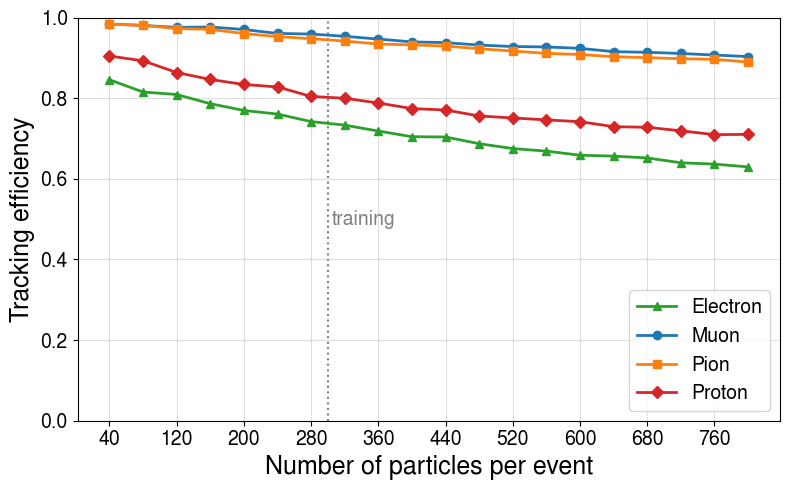

Saved: /data/alice/bkuipers/out_of_distribution_experiment/ood_efficiency_helix_GT.pdf


In [10]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

JSON_PATH = Path("/data/alice/bkuipers/out_of_distribution_experiment/ood_efficiency_data_helix_GT.json")
OUT_PATH  = Path("/data/alice/bkuipers/out_of_distribution_experiment/ood_efficiency_helix_GT.pdf")

with open(JSON_PATH) as f:
    cache = json.load(f)

species = cache["per_species"]
SPECIES_COLORS  = {"Muon": "#1f77b4", "Pion": "#ff7f0e", "Electron": "#2ca02c", "Proton": "#d62728"}
SPECIES_MARKERS = {"Muon": "o", "Pion": "s", "Electron": "^", "Proton": "D"}

fig, ax = plt.subplots(figsize=(8, 5))
for name, d in sorted(species.items()):
    ax.plot(d["x"], [e / 100 for e in d["eff"]],
            marker=SPECIES_MARKERS.get(name, "o"),
            color=SPECIES_COLORS.get(name, "gray"),
            lw=2, markersize=6, label=name)

ax.axvline(300, color="gray", lw=1.5, linestyle=":", zorder=0)
ax.text(305, 0.5, "training", ha="left", va="center", fontsize=14, color="gray")
ax.set_xlabel("Number of particles per event", fontsize=18)
ax.set_ylabel("Tracking efficiency", fontsize=18)
#ax.set_title("OOD Sweep: Tracking Efficiency vs Multiplicity", fontsize=18)
ax.tick_params(labelsize=14)
x_all = cache["overall"]["x"]
ax.set_xticks(x_all[::2])
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.4)
ax.legend(fontsize=14, loc="lower right")
fig.tight_layout()
fig.savefig(OUT_PATH, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_PATH}")

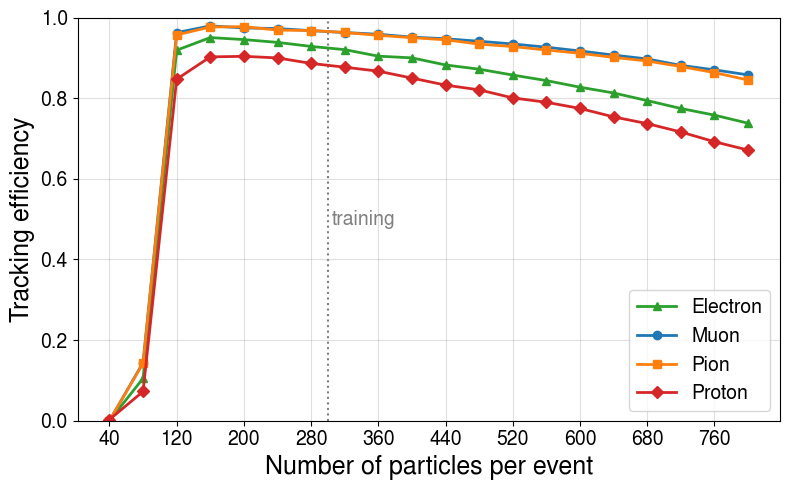

Saved: /data/alice/bkuipers/out_of_distribution_experiment/ood_efficiency_segmentGNN.pdf


In [11]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

JSON_PATH = Path("/data/alice/bkuipers/out_of_distribution_experiment/ood_efficiency_data_segmentGNN.json")
OUT_PATH  = Path("/data/alice/bkuipers/out_of_distribution_experiment/ood_efficiency_segmentGNN.pdf")

with open(JSON_PATH) as f:
    cache = json.load(f)

species = cache["per_species"]
SPECIES_COLORS  = {"Muon": "#1f77b4", "Pion": "#ff7f0e", "Electron": "#2ca02c", "Proton": "#d62728"}
SPECIES_MARKERS = {"Muon": "o", "Pion": "s", "Electron": "^", "Proton": "D"}

fig, ax = plt.subplots(figsize=(8, 5))
for name, d in sorted(species.items()):
    ax.plot(d["x"], [e / 100 for e in d["eff"]],
            marker=SPECIES_MARKERS.get(name, "o"),
            color=SPECIES_COLORS.get(name, "gray"),
            lw=2, markersize=6, label=name)

ax.axvline(300, color="gray", lw=1.5, linestyle=":", zorder=0)
ax.text(305, 0.5, "training", ha="left", va="center", fontsize=14, color="gray")
ax.set_xlabel("Number of particles per event", fontsize=18)
ax.set_ylabel("Tracking efficiency", fontsize=18)
#ax.set_title("OOD Sweep: Tracking Efficiency vs Multiplicity (Segment GNN)", fontsize=18)
ax.tick_params(labelsize=14)
x_all = cache["overall"]["x"]
ax.set_xticks(x_all[::2])
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.4)
ax.legend(fontsize=14, loc="lower right")
fig.tight_layout()
fig.savefig(OUT_PATH, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_PATH}")